In [7]:
# =============================================================================
# CHECKPOINTED / RELAXED Full rs-fMRI Pipeline
# Leakage-aware Group ICA vs Intentionally Leaky Group ICA
#
# This version is designed to avoid wasting long denoising runs.
#
# Major fixes:
#   1. Per-subject checkpointing.
#   2. Native cleaned image is saved immediately.
#   3. Common-grid resampled image is saved separately.
#   4. On rerun, completed subjects are skipped.
#   5. Subject masks are resampled to a reference grid before common-mask creation.
#   6. Denoising has fallback strategies instead of failing immediately.
#
# Output folder:
#   H:\Master's Thesis\pipeline\analysis_outputs_checkpointed_relaxed
#
# Interpretation:
#   This is less strict than the ideal manuscript pipeline because it uses fallback
#   cleaning strategies when the preferred denoising fails. The exact strategy used
#   for each subject is saved in the manifest.
# =============================================================================


# =============================================================================
# IMPORTS
# =============================================================================

import os
import json
import time
import shutil
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import nibabel as nib

from nilearn.image import clean_img, resample_to_img
from nilearn import decomposition
from nilearn.connectome import ConnectivityMeasure

from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# =============================================================================
# USER SETTINGS
# =============================================================================

ROOT_DIR = Path(r"H:\Master's Thesis\pipeline")
LABEL_CSV = ROOT_DIR / "full dataset.csv"

OUT_DIR = ROOT_DIR / "analysis_outputs_checkpointed_relaxed"

SUBJECT_COLUMN = "Subject ID"
LABEL_COLUMN = "label"

VALID_LABELS = {
    "CN": 0,
    "AD": 1
}

BOLD_PATTERN = "*_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"
FUNC_MASK_PATTERN = "*_task-rest_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"
CONFOUNDS_PATTERN = "*_task-rest_desc-confounds_timeseries.tsv"

SESSION_RULE = "earliest"

# Denoising target strategy.
DENOISE_DETREND = True
DENOISE_STANDARDIZE = "zscore_sample"
DENOISE_HIGH_PASS = 0.01
DENOISE_LOW_PASS = 0.10
DEFAULT_TR_SECONDS = 3.0

MOTION_COLUMNS = [
    "trans_x", "trans_y", "trans_z",
    "rot_x", "rot_y", "rot_z"
]

TISSUE_COLUMNS = [
    "white_matter",
    "csf"
]

INCLUDE_COSINE_CONFOUNDS = True
INCLUDE_NON_STEADY_STATE_OUTLIERS = True
INCLUDE_GLOBAL_SIGNAL = False

# Less strict common mask.
# 0.50 means a voxel is retained if it is in at least 50% of subject masks
# after resampling to the reference grid.
COMMON_MASK_THRESHOLD = 0.50

# Checkpoint behavior.
FORCE_REBUILD_DENOISING = False
FORCE_REBUILD_MASKS = False
FORCE_REBUILD_MODELS = False

# If True, the script will stop after denoising and writing manifests.
# Useful if you want to validate cleaning before running ICA/SVM.
RUN_DENOISING_ONLY = False

# Model settings.
RANDOM_STATE = 42
N_OUTER_SPLITS = 5
N_INNER_SPLITS = 5
N_COMPONENTS = 40

WIN_SIZE = 20
STEP_SIZE = 10

N_OPTUNA_TRIALS = 50
N_BOOTSTRAPS = 1000
CI_LEVEL = 95

APPLY_FISHER_Z = False

# Output folders.
MANIFEST_DIR = OUT_DIR / "manifests"
NATIVE_CLEANED_DIR = OUT_DIR / "cleaned_native_grid"
COMMON_CLEANED_DIR = OUT_DIR / "cleaned_common_grid"
MASK_DIR = OUT_DIR / "masks"
RESAMPLED_MASK_DIR = MASK_DIR / "resampled_subject_masks"
RESULTS_DIR = OUT_DIR / "results"
NILEARN_CACHE_DIR = OUT_DIR / "nilearn_cache"

for folder in [
    OUT_DIR,
    MANIFEST_DIR,
    NATIVE_CLEANED_DIR,
    COMMON_CLEANED_DIR,
    MASK_DIR,
    RESAMPLED_MASK_DIR,
    RESULTS_DIR,
    NILEARN_CACHE_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)


# =============================================================================
# BASIC HELPERS
# =============================================================================

def log(message):
    print(message, flush=True)


def require_path(path, name):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"{name} not found:\n{path}")
    return path


def read_table_auto(path):
    path = Path(path)

    try:
        df = pd.read_csv(path, sep=None, engine="python")
    except Exception:
        df = pd.read_csv(path)

    if df.shape[1] == 1:
        for sep in ["\t", ";", ","]:
            try:
                temp = pd.read_csv(path, sep=sep)
                if temp.shape[1] > 1:
                    df = temp
                    break
            except Exception:
                pass

    df.columns = [str(c).strip() for c in df.columns]
    return df


def find_single_or_choose(files, rule="earliest"):
    files = sorted([Path(f) for f in files])

    if len(files) == 0:
        return None

    if rule == "latest":
        return files[-1]

    return files[0]


def extract_session_id(path):
    path = Path(path)
    for part in path.parts:
        if part.startswith("ses-"):
            return part
    return ""


def get_tr_seconds(nifti_path, default_tr=DEFAULT_TR_SECONDS):
    try:
        img = nib.load(str(nifti_path))
        zooms = img.header.get_zooms()
        if len(zooms) >= 4:
            tr = float(zooms[3])
            if np.isfinite(tr) and tr > 0:
                return tr
    except Exception:
        pass

    return float(default_tr)


def is_valid_nifti(path):
    path = Path(path)
    if not path.exists():
        return False

    try:
        img = nib.load(str(path))
        _ = img.shape
        return True
    except Exception:
        return False


def safe_fisher_z(x):
    x = np.asarray(x, dtype=float)
    x = np.clip(x, -0.999999, 0.999999)
    return np.arctanh(x)


def save_checkpoint(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


# =============================================================================
# LOAD LABELS AND SCAN SUBJECT FILES
# =============================================================================

def load_labels(label_csv):
    require_path(label_csv, "Label CSV")

    df = read_table_auto(label_csv)

    if SUBJECT_COLUMN not in df.columns:
        raise ValueError(
            f"Column '{SUBJECT_COLUMN}' was not found in label CSV.\n"
            f"Available columns:\n{df.columns.tolist()}"
        )

    if LABEL_COLUMN not in df.columns:
        raise ValueError(
            f"Column '{LABEL_COLUMN}' was not found in label CSV.\n"
            f"Available columns:\n{df.columns.tolist()}"
        )

    df[SUBJECT_COLUMN] = df[SUBJECT_COLUMN].astype(str).str.strip()
    df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip().str.upper()

    df = df[df[SUBJECT_COLUMN].notna()]
    df = df[df[SUBJECT_COLUMN] != ""]
    df = df[df[LABEL_COLUMN].isin(VALID_LABELS.keys())].copy()

    if df.empty:
        raise ValueError("No usable AD/CN rows were found in the label CSV.")

    duplicated = df[df.duplicated(SUBJECT_COLUMN, keep=False)].copy()

    if not duplicated.empty:
        conflict_table = duplicated.groupby(SUBJECT_COLUMN)[LABEL_COLUMN].nunique()
        conflicts = conflict_table[conflict_table > 1]

        if len(conflicts) > 0:
            raise ValueError(
                "Some subjects have conflicting labels in the CSV:\n"
                f"{conflicts.index.tolist()[:20]}"
            )

        log(
            f"Warning: {duplicated[SUBJECT_COLUMN].nunique()} subjects have duplicate rows. "
            "Keeping the first row per subject."
        )

    df = df.drop_duplicates(subset=[SUBJECT_COLUMN], keep="first").copy()

    return df


def scan_subject_files(labels_df):
    rows = []

    for _, row in labels_df.iterrows():
        subject_id = str(row[SUBJECT_COLUMN]).strip()
        label_name = str(row[LABEL_COLUMN]).strip().upper()
        label_value = VALID_LABELS[label_name]

        subject_dir = ROOT_DIR / subject_id

        record = {
            "subject_id": subject_id,
            "label_name": label_name,
            "label": label_value,
            "subject_dir": str(subject_dir),
            "subject_dir_exists": subject_dir.exists(),
            "session_id": "",
            "bold_path": "",
            "func_mask_path": "",
            "confounds_path": "",
            "tr_seconds": np.nan,
            "status": "pending",
            "exclusion_reason": ""
        }

        for optional_col in [
            "Sex",
            "Scan_Age",
            "Phase",
            "fMRI_Description",
            "fMRI_Imaging_Protocol"
        ]:
            if optional_col in labels_df.columns:
                record[optional_col] = row.get(optional_col, np.nan)

        if not subject_dir.exists():
            record["status"] = "excluded"
            record["exclusion_reason"] = "subject folder not found"
            rows.append(record)
            continue

        bold_files = list(subject_dir.glob(f"ses-*/func/{BOLD_PATTERN}"))
        mask_files = list(subject_dir.glob(f"ses-*/func/{FUNC_MASK_PATTERN}"))
        confound_files = list(subject_dir.glob(f"ses-*/func/{CONFOUNDS_PATTERN}"))

        bold_path = find_single_or_choose(bold_files, SESSION_RULE)
        mask_path = find_single_or_choose(mask_files, SESSION_RULE)
        confounds_path = find_single_or_choose(confound_files, SESSION_RULE)

        if bold_path is None:
            record["status"] = "excluded"
            record["exclusion_reason"] = "preprocessed BOLD file not found"
            rows.append(record)
            continue

        if mask_path is None:
            record["status"] = "excluded"
            record["exclusion_reason"] = "functional brain mask file not found"
            rows.append(record)
            continue

        if confounds_path is None:
            record["status"] = "excluded"
            record["exclusion_reason"] = "confounds TSV file not found"
            rows.append(record)
            continue

        record["session_id"] = extract_session_id(bold_path)
        record["bold_path"] = str(bold_path)
        record["func_mask_path"] = str(mask_path)
        record["confounds_path"] = str(confounds_path)
        record["tr_seconds"] = get_tr_seconds(bold_path)
        record["status"] = "valid"
        record["exclusion_reason"] = ""

        rows.append(record)

    return pd.DataFrame(rows)


# =============================================================================
# COMMON GRID AND MASK
# =============================================================================

def choose_reference_bold(valid_manifest):
    """
    Choose the first valid BOLD file as the reference grid.
    All masks and cleaned images are resampled to this grid.
    """
    if valid_manifest.empty:
        raise ValueError("No valid subjects available for reference selection.")

    reference_path = Path(valid_manifest.iloc[0]["bold_path"])
    require_path(reference_path, "Reference BOLD")

    reference_copy_path = MASK_DIR / "reference_bold_grid.nii.gz"

    if not reference_copy_path.exists() or FORCE_REBUILD_MASKS:
        shutil.copyfile(reference_path, reference_copy_path)

    return reference_path, reference_copy_path


def resample_subject_masks_to_reference(valid_manifest, reference_img_path):
    """
    Resample every subject's fMRIPrep functional mask to the reference BOLD grid.
    Saves after every subject, so reruns skip completed masks.
    """
    reference_img = nib.load(str(reference_img_path))
    rows = []

    for counter, (_, row) in enumerate(valid_manifest.iterrows(), start=1):
        subject_id = row["subject_id"]
        session_id = row["session_id"]
        source_mask_path = Path(row["func_mask_path"])

        out_mask_path = RESAMPLED_MASK_DIR / f"{subject_id}_{session_id}_func_mask_referencegrid.nii.gz"

        record = row.to_dict()
        record["resampled_mask_path"] = str(out_mask_path)
        record["mask_resample_status"] = "pending"
        record["mask_resample_error"] = ""

        if is_valid_nifti(out_mask_path) and not FORCE_REBUILD_MASKS:
            record["mask_resample_status"] = "existing"
            rows.append(record)
            continue

        try:
            log(f"Resampling mask {subject_id} ({counter}/{len(valid_manifest)})...")

            resampled = resample_to_img(
                source_img=str(source_mask_path),
                target_img=reference_img,
                interpolation="nearest"
            )

            mask_data = (resampled.get_fdata() > 0.5).astype(np.uint8)
            mask_img = nib.Nifti1Image(mask_data, reference_img.affine, reference_img.header)
            mask_img.to_filename(str(out_mask_path))

            record["mask_resample_status"] = "resampled"

        except Exception as e:
            record["mask_resample_status"] = "failed"
            record["mask_resample_error"] = repr(e)

        rows.append(record)

        save_checkpoint(
            pd.DataFrame(rows),
            MANIFEST_DIR / "mask_resampling_checkpoint_partial.csv"
        )

    mask_manifest = pd.DataFrame(rows)
    mask_manifest.to_csv(MANIFEST_DIR / "mask_resampling_manifest.csv", index=False)

    valid_masks = mask_manifest[
        mask_manifest["mask_resample_status"].isin(["existing", "resampled"])
    ].copy()

    if valid_masks.empty:
        raise ValueError("No masks were successfully resampled to the reference grid.")

    return mask_manifest, valid_masks


def build_common_mask_from_resampled_masks(mask_manifest):
    common_mask_path = MASK_DIR / "common_mask_referencegrid.nii.gz"

    if is_valid_nifti(common_mask_path) and not FORCE_REBUILD_MASKS:
        log(f"Using existing common mask:\n{common_mask_path}")
        return common_mask_path

    valid = mask_manifest[
        mask_manifest["mask_resample_status"].isin(["existing", "resampled"])
    ].copy()

    if valid.empty:
        raise ValueError("No valid resampled masks available for common mask creation.")

    first_mask = nib.load(valid.iloc[0]["resampled_mask_path"])
    ref_affine = first_mask.affine
    ref_header = first_mask.header
    ref_shape = first_mask.shape

    mask_sum = np.zeros(ref_shape, dtype=np.float32)
    n_masks = 0

    for _, row in valid.iterrows():
        path = row["resampled_mask_path"]
        img = nib.load(path)

        if img.shape != ref_shape:
            log(f"Skipping mask with unexpected shape: {path}")
            continue

        data = img.get_fdata() > 0.5
        mask_sum += data.astype(np.float32)
        n_masks += 1

    if n_masks == 0:
        raise ValueError("No masks could be accumulated for common mask.")

    proportion = mask_sum / float(n_masks)
    common_data = (proportion >= COMMON_MASK_THRESHOLD).astype(np.uint8)

    n_voxels = int(common_data.sum())

    if n_voxels == 0:
        raise ValueError(
            "The common mask is empty. Lower COMMON_MASK_THRESHOLD, e.g., 0.25."
        )

    common_img = nib.Nifti1Image(common_data, ref_affine, ref_header)
    common_img.to_filename(str(common_mask_path))

    log(f"Saved common mask:\n{common_mask_path}")
    log(f"Common mask threshold: {COMMON_MASK_THRESHOLD}")
    log(f"Number of masks used: {n_masks}")
    log(f"Common mask voxels: {n_voxels}")

    return common_mask_path


# =============================================================================
# CONFOUNDS AND CHECKPOINTED DENOISING
# =============================================================================

def get_confounds(confounds_path, n_vols=None):
    confounds_df = pd.read_csv(confounds_path, sep="\t")

    selected_cols = []

    for col in MOTION_COLUMNS:
        if col in confounds_df.columns:
            selected_cols.append(col)

    for col in TISSUE_COLUMNS:
        if col in confounds_df.columns:
            selected_cols.append(col)

    if INCLUDE_GLOBAL_SIGNAL and "global_signal" in confounds_df.columns:
        selected_cols.append("global_signal")

    if INCLUDE_COSINE_CONFOUNDS:
        cosine_cols = [c for c in confounds_df.columns if c.startswith("cosine")]
        selected_cols.extend(cosine_cols)

    if INCLUDE_NON_STEADY_STATE_OUTLIERS:
        nss_cols = [c for c in confounds_df.columns if c.startswith("non_steady_state_outlier")]
        selected_cols.extend(nss_cols)

    selected_cols = list(dict.fromkeys(selected_cols))

    if len(selected_cols) == 0:
        return None, [], "no_confounds_available"

    confounds = confounds_df[selected_cols].copy()
    confounds = confounds.replace(["n/a", "N/A", "nan", "NaN", "inf", "-inf"], np.nan)
    confounds = confounds.apply(pd.to_numeric, errors="coerce")
    confounds = confounds.fillna(0.0)

    length_note = "matched"

    if n_vols is not None:
        if confounds.shape[0] > n_vols:
            confounds = confounds.iloc[:n_vols, :].copy()
            length_note = "truncated_to_bold_length"

        elif confounds.shape[0] < n_vols:
            missing = n_vols - confounds.shape[0]
            pad = pd.DataFrame(
                np.zeros((missing, confounds.shape[1])),
                columns=confounds.columns
            )
            confounds = pd.concat([confounds, pad], ignore_index=True)
            length_note = "zero_padded_to_bold_length"

    return confounds, selected_cols, length_note


def denoise_one_subject_with_fallbacks(
    bold_path,
    subject_mask_path,
    confounds_path,
    native_cleaned_path,
    tr_seconds
):
    """
    Try several cleaning strategies.

    Preferred:
        confounds + bandpass + subject-specific mask

    Fallbacks:
        confounds + no temporal filtering + subject-specific mask
        confounds + bandpass + no mask
        no confounds + no temporal filtering + subject-specific mask
        no confounds + no temporal filtering + no mask

    The fallback choices make the pipeline less strict but much more robust.
    The exact strategy used is saved per subject.
    """
    bold_img = nib.load(str(bold_path))

    if len(bold_img.shape) != 4:
        raise ValueError(f"BOLD image is not 4D. Shape={bold_img.shape}")

    n_vols = int(bold_img.shape[3])

    confounds, selected_cols, length_note = get_confounds(confounds_path, n_vols=n_vols)

    strategies = [
        {
            "name": "preferred_confounds_bandpass_subject_mask",
            "confounds": confounds,
            "low_pass": DENOISE_LOW_PASS,
            "high_pass": DENOISE_HIGH_PASS,
            "mask_img": str(subject_mask_path)
        },
        {
            "name": "fallback_confounds_no_filter_subject_mask",
            "confounds": confounds,
            "low_pass": None,
            "high_pass": None,
            "mask_img": str(subject_mask_path)
        },
        {
            "name": "fallback_confounds_bandpass_no_mask",
            "confounds": confounds,
            "low_pass": DENOISE_LOW_PASS,
            "high_pass": DENOISE_HIGH_PASS,
            "mask_img": None
        },
        {
            "name": "fallback_no_confounds_no_filter_subject_mask",
            "confounds": None,
            "low_pass": None,
            "high_pass": None,
            "mask_img": str(subject_mask_path)
        },
        {
            "name": "fallback_no_confounds_no_filter_no_mask",
            "confounds": None,
            "low_pass": None,
            "high_pass": None,
            "mask_img": None
        }
    ]

    errors = []

    for strategy in strategies:
        try:
            cleaned_img = clean_img(
                imgs=str(bold_path),
                confounds=strategy["confounds"],
                t_r=tr_seconds,
                detrend=DENOISE_DETREND,
                standardize=DENOISE_STANDARDIZE,
                low_pass=strategy["low_pass"],
                high_pass=strategy["high_pass"],
                mask_img=strategy["mask_img"],
                ensure_finite=True
            )

            cleaned_img.to_filename(str(native_cleaned_path))

            return {
                "status": "cleaned",
                "strategy": strategy["name"],
                "error": "",
                "n_volumes_bold": n_vols,
                "confounds_used": ";".join(selected_cols),
                "n_confounds_used": len(selected_cols),
                "confounds_length_note": length_note
            }

        except Exception as e:
            errors.append(f"{strategy['name']}: {repr(e)}")

    return {
        "status": "failed",
        "strategy": "all_strategies_failed",
        "error": " || ".join(errors),
        "n_volumes_bold": n_vols,
        "confounds_used": ";".join(selected_cols),
        "n_confounds_used": len(selected_cols),
        "confounds_length_note": length_note
    }


def resample_cleaned_to_reference(native_cleaned_path, reference_img_path, common_cleaned_path):
    reference_img = nib.load(str(reference_img_path))

    resampled_img = resample_to_img(
        source_img=str(native_cleaned_path),
        target_img=reference_img,
        interpolation="continuous"
    )

    resampled_img.to_filename(str(common_cleaned_path))


def checkpointed_denoise_all_subjects(valid_manifest, reference_img_path):
    checkpoint_path = MANIFEST_DIR / "denoising_checkpoint.csv"
    final_manifest_path = MANIFEST_DIR / "cleaned_bold_manifest_all.csv"

    rows = []

    if checkpoint_path.exists():
        try:
            previous = pd.read_csv(checkpoint_path)
            previous_by_subject = {
                str(r["subject_id"]): r.to_dict()
                for _, r in previous.iterrows()
                if "subject_id" in previous.columns
            }
        except Exception:
            previous_by_subject = {}
    else:
        previous_by_subject = {}

    for counter, (_, row) in enumerate(valid_manifest.iterrows(), start=1):
        subject_id = row["subject_id"]
        session_id = row["session_id"]

        bold_path = Path(row["bold_path"])
        subject_mask_path = Path(row["func_mask_path"])
        confounds_path = Path(row["confounds_path"])

        tr_seconds = float(row["tr_seconds"]) if pd.notna(row["tr_seconds"]) else DEFAULT_TR_SECONDS

        native_cleaned_path = NATIVE_CLEANED_DIR / f"{subject_id}_{session_id}_task-rest_cleaned_nativegrid_bold.nii.gz"
        common_cleaned_path = COMMON_CLEANED_DIR / f"{subject_id}_{session_id}_task-rest_cleaned_commongrid_bold.nii.gz"

        record = row.to_dict()
        record["native_cleaned_bold_path"] = str(native_cleaned_path)
        record["cleaned_bold_path"] = str(common_cleaned_path)
        record["denoise_status"] = "pending"
        record["denoise_error"] = ""
        record["cleaning_strategy_used"] = ""
        record["n_volumes_bold"] = np.nan
        record["confounds_used"] = ""
        record["n_confounds_used"] = 0
        record["confounds_length_note"] = ""
        record["native_cleaned_exists"] = False
        record["common_grid_cleaned_exists"] = False
        record["resample_status"] = "pending"
        record["resample_error"] = ""

        # Fast skip if the final common-grid file already exists.
        if is_valid_nifti(common_cleaned_path) and not FORCE_REBUILD_DENOISING:
            previous_record = previous_by_subject.get(subject_id, {})
            record.update({k: v for k, v in previous_record.items() if k in record})
            record["denoise_status"] = "existing"
            record["resample_status"] = "existing"
            record["native_cleaned_exists"] = is_valid_nifti(native_cleaned_path)
            record["common_grid_cleaned_exists"] = True

            rows.append(record)
            save_checkpoint(pd.DataFrame(rows), checkpoint_path)
            continue

        log(f"Subject {subject_id} ({counter}/{len(valid_manifest)})")

        # Stage 1: native-grid cleaned image.
        if is_valid_nifti(native_cleaned_path) and not FORCE_REBUILD_DENOISING:
            log("  Native cleaned checkpoint exists. Skipping cleaning stage.")
            previous_record = previous_by_subject.get(subject_id, {})
            record.update({k: v for k, v in previous_record.items() if k in record})
            record["denoise_status"] = "existing_native"
            record["native_cleaned_exists"] = True

        else:
            log("  Cleaning native-grid BOLD...")
            result = denoise_one_subject_with_fallbacks(
                bold_path=bold_path,
                subject_mask_path=subject_mask_path,
                confounds_path=confounds_path,
                native_cleaned_path=native_cleaned_path,
                tr_seconds=tr_seconds
            )

            record["denoise_status"] = result["status"]
            record["denoise_error"] = result["error"]
            record["cleaning_strategy_used"] = result["strategy"]
            record["n_volumes_bold"] = result["n_volumes_bold"]
            record["confounds_used"] = result["confounds_used"]
            record["n_confounds_used"] = result["n_confounds_used"]
            record["confounds_length_note"] = result["confounds_length_note"]
            record["native_cleaned_exists"] = is_valid_nifti(native_cleaned_path)

        # Save checkpoint immediately after native cleaning attempt.
        rows.append(record)
        save_checkpoint(pd.DataFrame(rows), checkpoint_path)

        # If native cleaning failed, do not attempt resampling.
        if not is_valid_nifti(native_cleaned_path):
            record["denoise_status"] = "failed"
            record["resample_status"] = "skipped_no_native_cleaned_file"
            rows[-1] = record
            save_checkpoint(pd.DataFrame(rows), checkpoint_path)
            continue

        # Stage 2: resample native cleaned image to common/reference grid.
        if is_valid_nifti(common_cleaned_path) and not FORCE_REBUILD_DENOISING:
            log("  Common-grid cleaned checkpoint exists. Skipping resampling stage.")
            record["resample_status"] = "existing"
            record["common_grid_cleaned_exists"] = True

        else:
            try:
                log("  Resampling cleaned image to reference/common grid...")
                resample_cleaned_to_reference(
                    native_cleaned_path=native_cleaned_path,
                    reference_img_path=reference_img_path,
                    common_cleaned_path=common_cleaned_path
                )
                record["resample_status"] = "resampled"
                record["resample_error"] = ""
                record["common_grid_cleaned_exists"] = is_valid_nifti(common_cleaned_path)

            except Exception as e:
                record["resample_status"] = "failed"
                record["resample_error"] = repr(e)
                record["common_grid_cleaned_exists"] = False

        rows[-1] = record
        save_checkpoint(pd.DataFrame(rows), checkpoint_path)

    cleaned_manifest = pd.DataFrame(rows)
    cleaned_manifest.to_csv(final_manifest_path, index=False)

    valid_cleaned = cleaned_manifest[
        cleaned_manifest["common_grid_cleaned_exists"] == True
    ].copy()

    valid_cleaned.to_csv(MANIFEST_DIR / "cleaned_bold_manifest_valid.csv", index=False)

    return cleaned_manifest, valid_cleaned


# =============================================================================
# FEATURE EXTRACTION AND MODELING
# =============================================================================

def fit_ica(paths, mask_img_path):
    ica = decomposition.CanICA(
        n_components=N_COMPONENTS,
        mask=str(mask_img_path),
        memory=str(NILEARN_CACHE_DIR),
        memory_level=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=0
    )

    ica.fit(paths)

    return ica


def extract_features_from_ica(ica_obj, img_paths, label_for_print=""):
    static_measure = ConnectivityMeasure(kind="correlation")
    partial_measure = ConnectivityMeasure(
        kind="partial correlation",
        cov_estimator=LedoitWolf()
    )

    triu = np.triu_indices(N_COMPONENTS, k=1)
    expected_n_features = 4 * (N_COMPONENTS * (N_COMPONENTS - 1) // 2)

    all_features = []

    for i, img_path in enumerate(img_paths, start=1):
        print(f"    {label_for_print}: extracting features {i}/{len(img_paths)}", end="\r")

        ts = ica_obj.transform([img_path])[0]

        if ts.ndim != 2:
            raise ValueError(f"ICA transform returned invalid shape {ts.shape} for:\n{img_path}")

        if ts.shape[1] != N_COMPONENTS:
            raise ValueError(
                f"Expected {N_COMPONENTS} ICA time series, got {ts.shape[1]} for:\n{img_path}"
            )

        n_vols = ts.shape[0]

        if n_vols < WIN_SIZE:
            raise ValueError(
                f"Too few volumes for dynamic FC: n_vols={n_vols}, WIN_SIZE={WIN_SIZE}, path={img_path}"
            )

        static_mat = static_measure.fit_transform([ts])[0]

        n_windows = (n_vols - WIN_SIZE) // STEP_SIZE + 1

        if n_windows < 1:
            raise ValueError(
                f"No valid dFC windows: n_vols={n_vols}, WIN_SIZE={WIN_SIZE}, STEP_SIZE={STEP_SIZE}, path={img_path}"
            )

        window_mats = []

        for window_idx in range(n_windows):
            start = window_idx * STEP_SIZE
            stop = start + WIN_SIZE
            win_ts = ts[start:stop, :]
            win_mat = static_measure.fit_transform([win_ts])[0]
            window_mats.append(win_mat)

        window_mats = np.asarray(window_mats)
        dyn_mean = window_mats.mean(axis=0)
        dyn_std = window_mats.std(axis=0)

        partial_mat = partial_measure.fit_transform([ts])[0]

        static_vec = static_mat[triu]
        dyn_mean_vec = dyn_mean[triu]
        dyn_std_vec = dyn_std[triu]
        partial_vec = partial_mat[triu]

        if APPLY_FISHER_Z:
            static_vec = safe_fisher_z(static_vec)
            dyn_mean_vec = safe_fisher_z(dyn_mean_vec)
            partial_vec = safe_fisher_z(partial_vec)

        feature_vector = np.concatenate([
            static_vec,
            dyn_mean_vec,
            dyn_std_vec,
            partial_vec
        ]).astype(np.float32)

        if feature_vector.shape[0] != expected_n_features:
            raise ValueError(
                f"Unexpected feature length: got {feature_vector.shape[0]}, expected {expected_n_features}"
            )

        all_features.append(feature_vector)

    print(" " * 120, end="\r")

    return np.asarray(all_features, dtype=np.float32)


def make_svm_pipeline(C):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="linear",
            C=C,
            class_weight="balanced",
            probability=False,
            random_state=RANDOM_STATE
        ))
    ])


def tune_C_with_optuna(X_train, y_train, model_name, fold_number):
    inner_cv = StratifiedKFold(
        n_splits=N_INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    def objective(trial):
        C = trial.suggest_float("C", 1e-3, 1e3, log=True)
        model = make_svm_pipeline(C=C)

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=inner_cv,
            scoring="balanced_accuracy",
            n_jobs=1
        )

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE)
    )

    study.optimize(
        objective,
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=False
    )

    best_C = float(study.best_params["C"])
    best_score = float(study.best_value)

    log(
        f"  {model_name} fold {fold_number}: "
        f"best C = {best_C:.6f}, inner balanced accuracy = {best_score:.4f}"
    )

    return best_C, best_score


def compute_metrics(y_true, y_pred, y_score):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_score = np.asarray(y_score)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sensitivity = recall_score(y_true, y_pred, pos_label=1, zero_division=0)

    auc_value = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "auc": float(auc_value),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def bootstrap_ci(y_true, y_pred, y_score, metric_name, n_boot=N_BOOTSTRAPS):
    rng = np.random.default_rng(RANDOM_STATE)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_score = np.asarray(y_score)

    n = len(y_true)
    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)

        if len(np.unique(y_true[idx])) < 2:
            continue

        value = compute_metrics(
            y_true[idx],
            y_pred[idx],
            y_score[idx]
        )[metric_name]

        values.append(value)

    if not values:
        return np.nan, np.nan

    alpha = (100 - CI_LEVEL) / 2.0

    return (
        float(np.percentile(values, alpha)),
        float(np.percentile(values, 100 - alpha))
    )


def paired_bootstrap_diff_ci(
    y_true,
    aware_pred,
    aware_score,
    leaky_pred,
    leaky_score,
    metric_name,
    n_boot=N_BOOTSTRAPS
):
    rng = np.random.default_rng(RANDOM_STATE)

    y_true = np.asarray(y_true)
    aware_pred = np.asarray(aware_pred)
    aware_score = np.asarray(aware_score)
    leaky_pred = np.asarray(leaky_pred)
    leaky_score = np.asarray(leaky_score)

    n = len(y_true)
    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)

        if len(np.unique(y_true[idx])) < 2:
            continue

        aware_metric = compute_metrics(
            y_true[idx],
            aware_pred[idx],
            aware_score[idx]
        )[metric_name]

        leaky_metric = compute_metrics(
            y_true[idx],
            leaky_pred[idx],
            leaky_score[idx]
        )[metric_name]

        values.append(leaky_metric - aware_metric)

    if not values:
        return np.nan, np.nan

    alpha = (100 - CI_LEVEL) / 2.0

    return (
        float(np.percentile(values, alpha)),
        float(np.percentile(values, 100 - alpha))
    )


def run_leakage_aware_model(outer_splits, cleaned_paths, labels, mask_path):
    log("\n" + "#" * 90)
    log("RUNNING LEAKAGE-AWARE MODEL")
    log("Group ICA is fitted only on the outer-training subjects in each fold.")
    log("#" * 90)

    n = len(labels)

    oof_pred = np.full(n, -1, dtype=int)
    oof_score = np.full(n, np.nan, dtype=float)
    fold_rows = []

    start_time = time.time()

    for fold_number, (train_idx, test_idx) in enumerate(outer_splits, start=1):
        log(f"\nLeakage-aware outer fold {fold_number}/{N_OUTER_SPLITS}")

        train_paths = [cleaned_paths[i] for i in train_idx]
        test_paths = [cleaned_paths[i] for i in test_idx]

        y_train = labels[train_idx]
        y_test = labels[test_idx]

        log("  Fitting Group ICA on training subjects only...")
        ica = fit_ica(train_paths, mask_path)

        log("  Extracting training features...")
        X_train = extract_features_from_ica(
            ica,
            train_paths,
            label_for_print=f"aware fold {fold_number} train"
        )

        log("  Extracting test features using training-derived ICA maps...")
        X_test = extract_features_from_ica(
            ica,
            test_paths,
            label_for_print=f"aware fold {fold_number} test"
        )

        log(f"  X_train shape: {X_train.shape}")
        log(f"  X_test shape:  {X_test.shape}")

        best_C, best_inner_score = tune_C_with_optuna(
            X_train,
            y_train,
            model_name="Leakage-aware",
            fold_number=fold_number
        )

        model = make_svm_pipeline(C=best_C)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_score = model.decision_function(X_test)

        oof_pred[test_idx] = y_pred
        oof_score[test_idx] = y_score

        metrics = compute_metrics(y_test, y_pred, y_score)

        fold_rows.append({
            "model": "leakage_aware",
            "fold": fold_number,
            "best_C": best_C,
            "inner_balanced_accuracy": best_inner_score,
            "n_train": int(len(train_idx)),
            "n_test": int(len(test_idx)),
            "n_train_CN": int(np.sum(y_train == 0)),
            "n_train_AD": int(np.sum(y_train == 1)),
            "n_test_CN": int(np.sum(y_test == 0)),
            "n_test_AD": int(np.sum(y_test == 1)),
            **metrics
        })

        log(
            f"  Test accuracy={metrics['accuracy']:.3f}, "
            f"balanced_accuracy={metrics['balanced_accuracy']:.3f}, "
            f"AUC={metrics['auc']:.3f}, "
            f"F1={metrics['f1']:.3f}, "
            f"sensitivity={metrics['sensitivity']:.3f}, "
            f"specificity={metrics['specificity']:.3f}"
        )

    runtime = time.time() - start_time

    return pd.DataFrame(fold_rows), oof_pred, oof_score, runtime


def run_leaky_ica_model(outer_splits, cleaned_paths, labels, mask_path):
    log("\n" + "#" * 90)
    log("RUNNING LEAKY ICA MODEL")
    log("Group ICA is fitted once on the FULL cohort before cross-validation.")
    log("Future test subjects therefore contribute to ICA spatial-map estimation.")
    log("#" * 90)

    n = len(labels)

    oof_pred = np.full(n, -1, dtype=int)
    oof_score = np.full(n, np.nan, dtype=float)
    fold_rows = []

    start_time = time.time()

    log("\nFitting full-cohort Group ICA...")
    leaky_ica = fit_ica(cleaned_paths, mask_path)

    log("Extracting full-cohort leaky features...")
    X_all = extract_features_from_ica(
        leaky_ica,
        cleaned_paths,
        label_for_print="leaky full cohort"
    )

    log(f"X_all_leaky shape: {X_all.shape}")

    for fold_number, (train_idx, test_idx) in enumerate(outer_splits, start=1):
        log(f"\nLeaky ICA outer fold {fold_number}/{N_OUTER_SPLITS}")

        X_train = X_all[train_idx]
        X_test = X_all[test_idx]

        y_train = labels[train_idx]
        y_test = labels[test_idx]

        log(f"  X_train shape: {X_train.shape}")
        log(f"  X_test shape:  {X_test.shape}")

        best_C, best_inner_score = tune_C_with_optuna(
            X_train,
            y_train,
            model_name="Leaky ICA",
            fold_number=fold_number
        )

        model = make_svm_pipeline(C=best_C)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_score = model.decision_function(X_test)

        oof_pred[test_idx] = y_pred
        oof_score[test_idx] = y_score

        metrics = compute_metrics(y_test, y_pred, y_score)

        fold_rows.append({
            "model": "leaky_ica",
            "fold": fold_number,
            "best_C": best_C,
            "inner_balanced_accuracy": best_inner_score,
            "n_train": int(len(train_idx)),
            "n_test": int(len(test_idx)),
            "n_train_CN": int(np.sum(y_train == 0)),
            "n_train_AD": int(np.sum(y_train == 1)),
            "n_test_CN": int(np.sum(y_test == 0)),
            "n_test_AD": int(np.sum(y_test == 1)),
            **metrics
        })

        log(
            f"  Test accuracy={metrics['accuracy']:.3f}, "
            f"balanced_accuracy={metrics['balanced_accuracy']:.3f}, "
            f"AUC={metrics['auc']:.3f}, "
            f"F1={metrics['f1']:.3f}, "
            f"sensitivity={metrics['sensitivity']:.3f}, "
            f"specificity={metrics['specificity']:.3f}"
        )

    runtime = time.time() - start_time

    return pd.DataFrame(fold_rows), oof_pred, oof_score, runtime


def build_summary(labels, fold_df, oof_pred, oof_score, model_name, metric_names):
    pooled = compute_metrics(labels, oof_pred, oof_score)
    rows = []

    for metric in metric_names:
        ci_low, ci_high = bootstrap_ci(
            labels,
            oof_pred,
            oof_score,
            metric_name=metric
        )

        rows.append({
            "model": model_name,
            "metric": metric,
            "pooled_value": pooled[metric],
            "bootstrap_CI_low": ci_low,
            "bootstrap_CI_high": ci_high,
            "fold_mean": float(fold_df[metric].mean()),
            "fold_sd": float(fold_df[metric].std(ddof=0))
        })

    return pooled, pd.DataFrame(rows)


def build_difference_summary(
    labels,
    aware_pred,
    aware_score,
    leaky_pred,
    leaky_score,
    aware_pooled,
    leaky_pooled,
    metric_names
):
    rows = []

    for metric in metric_names:
        ci_low, ci_high = paired_bootstrap_diff_ci(
            labels,
            aware_pred,
            aware_score,
            leaky_pred,
            leaky_score,
            metric_name=metric
        )

        rows.append({
            "metric": metric,
            "leakage_aware_pooled": aware_pooled[metric],
            "leaky_ica_pooled": leaky_pooled[metric],
            "difference_leaky_minus_aware": leaky_pooled[metric] - aware_pooled[metric],
            "paired_bootstrap_CI_low": ci_low,
            "paired_bootstrap_CI_high": ci_high
        })

    return pd.DataFrame(rows)


def make_report(
    timestamp,
    n_subjects,
    n_cn,
    n_ad,
    n_excluded,
    n_edges,
    n_features,
    summary_df,
    difference_df,
    aware_cm,
    leaky_cm,
    common_mask_path
):
    lines = []

    lines.append("Leakage-aware vs Leaky ICA SVM Classification Report")
    lines.append("=" * 80)
    lines.append(f"Timestamp: {timestamp}")
    lines.append("")
    lines.append("Dataset and file selection")
    lines.append(f"- Root directory: {ROOT_DIR}")
    lines.append(f"- Label CSV: {LABEL_CSV}")
    lines.append(f"- Output directory: {OUT_DIR}")
    lines.append(f"- Total valid subjects used: {n_subjects}")
    lines.append(f"- Excluded subjects/rows before modeling: {n_excluded}")
    lines.append(f"- CN: {n_cn}")
    lines.append(f"- AD: {n_ad}")
    lines.append("- Positive class: AD")
    lines.append("- Negative class: CN")
    lines.append(f"- Session rule: {SESSION_RULE}")
    lines.append("")
    lines.append("Post-fMRIPrep cleaning")
    lines.append("- This checkpointed version uses fallback cleaning strategies when the preferred strategy fails.")
    lines.append("- Native-grid cleaned images are saved first, then resampled to a common reference grid.")
    lines.append("- The exact cleaning strategy used per subject is saved in cleaned_bold_manifest_all.csv.")
    lines.append("- Preferred confounds: 6 motion parameters, white matter, CSF, cosine regressors, and non-steady-state outliers when available.")
    lines.append(f"- Global signal regression: {INCLUDE_GLOBAL_SIGNAL}")
    lines.append(f"- Preferred high-pass: {DENOISE_HIGH_PASS} Hz")
    lines.append(f"- Preferred low-pass: {DENOISE_LOW_PASS} Hz")
    lines.append(f"- Detrend: {DENOISE_DETREND}")
    lines.append(f"- Standardization: {DENOISE_STANDARDIZE}")
    lines.append(f"- Common mask threshold after mask resampling: {COMMON_MASK_THRESHOLD}")
    lines.append(f"- Common analysis mask: {common_mask_path}")
    lines.append("")
    lines.append("Feature extraction")
    lines.append(f"- ICA components: {N_COMPONENTS}")
    lines.append(f"- Edges per connectivity matrix: {n_edges}")
    lines.append("- Feature blocks: static FC, dFC mean, dFC std, partial connectivity")
    lines.append(f"- Total features per subject: {n_features}")
    lines.append(f"- Dynamic FC window size: {WIN_SIZE} volumes")
    lines.append(f"- Dynamic FC step size: {STEP_SIZE} volumes")
    lines.append(f"- Fisher z-transform applied: {APPLY_FISHER_Z}")
    lines.append("")
    lines.append("Validation")
    lines.append(f"- Outer CV: stratified {N_OUTER_SPLITS}-fold, shuffle=True, random_state={RANDOM_STATE}")
    lines.append(f"- Inner CV: stratified {N_INNER_SPLITS}-fold, shuffle=True, random_state={RANDOM_STATE}")
    lines.append(f"- Optuna trials per outer fold: {N_OPTUNA_TRIALS}")
    lines.append("- Inner optimization metric: balanced accuracy")
    lines.append("- Classifier: linear SVM, class_weight='balanced'")
    lines.append("- Scaling: StandardScaler inside scikit-learn Pipeline")
    lines.append("")
    lines.append("Model definitions")
    lines.append("- Leakage-aware model: Group ICA fitted only on outer-training subjects.")
    lines.append("- Leaky ICA model: Group ICA fitted once on all subjects before CV.")
    lines.append("- The leaky model is intentionally contaminated at the representation-learning step and is not a valid generalization estimate.")
    lines.append("")
    lines.append("Pooled out-of-fold results")

    for model_name in ["leakage_aware", "leaky_ica"]:
        lines.append("")
        lines.append(model_name)
        model_summary = summary_df[summary_df["model"] == model_name]

        for _, row in model_summary.iterrows():
            lines.append(
                f"- {row['metric']}: "
                f"pooled={row['pooled_value']:.3f}, "
                f"{CI_LEVEL}% bootstrap CI=[{row['bootstrap_CI_low']:.3f}, {row['bootstrap_CI_high']:.3f}], "
                f"fold mean±SD={row['fold_mean']:.3f}±{row['fold_sd']:.3f}"
            )

    lines.append("")
    lines.append("Paired differences: leaky ICA minus leakage-aware")

    for _, row in difference_df.iterrows():
        lines.append(
            f"- {row['metric']}: "
            f"difference={row['difference_leaky_minus_aware']:.3f}, "
            f"{CI_LEVEL}% paired bootstrap CI=[{row['paired_bootstrap_CI_low']:.3f}, "
            f"{row['paired_bootstrap_CI_high']:.3f}]"
        )

    lines.append("")
    lines.append("Confusion matrices")
    lines.append("Labels are ordered as [CN=0, AD=1]. Matrix format: [[TN, FP], [FN, TP]].")
    lines.append("")
    lines.append("Leakage-aware confusion matrix:")
    lines.append(str(aware_cm))
    lines.append("")
    lines.append("Leaky ICA confusion matrix:")
    lines.append(str(leaky_cm))
    lines.append("")
    lines.append("Interpretation note")
    lines.append(
        "The leaky ICA result is not a valid estimate of generalization. "
        "It is a deliberately contaminated comparator used to quantify how fitting Group ICA "
        "on the full cohort before cross-validation changes apparent classification performance."
    )

    return "\n".join(lines)


# =============================================================================
# MAIN PIPELINE
# =============================================================================

pipeline_start = time.time()

log("\n" + "=" * 90)
log("STEP 1: LOAD LABEL CSV")
log("=" * 90)

labels_df = load_labels(LABEL_CSV)
labels_df.to_csv(MANIFEST_DIR / "labels_loaded.csv", index=False)

log(f"Loaded label rows after AD/CN filtering and de-duplication: {len(labels_df)}")
log(f"Label counts:\n{labels_df[LABEL_COLUMN].value_counts().to_string()}")


log("\n" + "=" * 90)
log("STEP 2: SCAN SUBJECT FOLDERS")
log("=" * 90)

manifest = scan_subject_files(labels_df)
manifest_path = MANIFEST_DIR / "subject_file_manifest_all.csv"
manifest.to_csv(manifest_path, index=False)

valid_manifest = manifest[manifest["status"] == "valid"].copy()

if valid_manifest.empty:
    raise ValueError(
        "No valid subjects found. Check subject_file_manifest_all.csv for exclusion reasons:\n"
        f"{manifest_path}"
    )

valid_manifest.to_csv(MANIFEST_DIR / "subject_file_manifest_valid.csv", index=False)

log(f"Total CSV subjects after label filtering: {len(labels_df)}")
log(f"Valid subjects with BOLD + mask + confounds: {len(valid_manifest)}")
log(f"Excluded subjects: {len(manifest) - len(valid_manifest)}")
log("\nValid label counts:")
log(valid_manifest["label_name"].value_counts().to_string())
log("\nExclusion reasons:")
log(manifest["exclusion_reason"].value_counts(dropna=False).to_string())


log("\n" + "=" * 90)
log("STEP 3: BUILD REFERENCE GRID AND COMMON MASK")
log("=" * 90)

reference_bold_path, reference_grid_copy_path = choose_reference_bold(valid_manifest)

log(f"Reference BOLD grid:\n{reference_bold_path}")
log(f"Reference BOLD copy:\n{reference_grid_copy_path}")

mask_manifest, valid_mask_manifest = resample_subject_masks_to_reference(
    valid_manifest=valid_manifest,
    reference_img_path=reference_bold_path
)

common_mask_path = build_common_mask_from_resampled_masks(mask_manifest)


log("\n" + "=" * 90)
log("STEP 4: CHECKPOINTED POST-fMRIPrep CLEANING / DENOISING")
log("=" * 90)

cleaned_manifest, valid_cleaned = checkpointed_denoise_all_subjects(
    valid_manifest=valid_manifest,
    reference_img_path=reference_bold_path
)

log(f"Subjects with usable common-grid cleaned BOLD: {len(valid_cleaned)}")
log("Denoise status counts:")
log(cleaned_manifest["denoise_status"].value_counts(dropna=False).to_string())
log("Resample status counts:")
log(cleaned_manifest["resample_status"].value_counts(dropna=False).to_string())

if RUN_DENOISING_ONLY:
    log("\nRUN_DENOISING_ONLY=True, stopping after denoising/checkpoint creation.")
    raise SystemExit


log("\n" + "=" * 90)
log("STEP 5: PREPARE MODEL INPUTS")
log("=" * 90)

subjects = valid_cleaned["subject_id"].astype(str).tolist()
labels = valid_cleaned["label"].astype(int).values
label_names = valid_cleaned["label_name"].astype(str).tolist()
cleaned_paths = valid_cleaned["cleaned_bold_path"].astype(str).tolist()

n_subjects = len(subjects)
n_cn = int(np.sum(labels == 0))
n_ad = int(np.sum(labels == 1))
n_edges = int(N_COMPONENTS * (N_COMPONENTS - 1) // 2)
n_features = int(n_edges * 4)

if n_subjects == 0:
    raise ValueError("Zero subjects available after cleaning.")

# Less strict than before:
# Reduce outer splits automatically if a class has fewer than N_OUTER_SPLITS.
actual_outer_splits = min(N_OUTER_SPLITS, n_cn, n_ad)

if actual_outer_splits < 2:
    raise ValueError(
        f"Not enough subjects per class for stratified CV. CN={n_cn}, AD={n_ad}."
    )

if actual_outer_splits != N_OUTER_SPLITS:
    log(
        f"Warning: requested {N_OUTER_SPLITS} outer folds, but only CN={n_cn}, AD={n_ad}. "
        f"Using {actual_outer_splits} outer folds instead."
    )

for path in cleaned_paths:
    require_path(path, "Cleaned common-grid BOLD file")

log(f"Total subjects used for classification: {n_subjects}")
log(f"CN: {n_cn}")
log(f"AD: {n_ad}")
log(f"Expected total features per subject: {n_features}")
log(f"Outer CV folds used: {actual_outer_splits}")


outer_cv = StratifiedKFold(
    n_splits=actual_outer_splits,
    shuffle=True,
    random_state=RANDOM_STATE
)

outer_splits = list(outer_cv.split(np.zeros(n_subjects), labels))

fold_assignment = np.zeros(n_subjects, dtype=int)

for fold_number, (_, test_idx) in enumerate(outer_splits, start=1):
    fold_assignment[test_idx] = fold_number

fold_df = pd.DataFrame({
    "subject_id": subjects,
    "label": labels,
    "label_name": label_names,
    "outer_fold": fold_assignment
})

fold_df.to_csv(MANIFEST_DIR / "outer_fold_assignments.csv", index=False)


log("\n" + "=" * 90)
log("STEP 6: RUN CLASSIFICATION MODELS")
log("=" * 90)

aware_fold_df, aware_oof_pred, aware_oof_score, aware_runtime = run_leakage_aware_model(
    outer_splits=outer_splits,
    cleaned_paths=cleaned_paths,
    labels=labels,
    mask_path=common_mask_path
)

leaky_fold_df, leaky_oof_pred, leaky_oof_score, leaky_runtime = run_leaky_ica_model(
    outer_splits=outer_splits,
    cleaned_paths=cleaned_paths,
    labels=labels,
    mask_path=common_mask_path
)


if np.any(aware_oof_pred == -1):
    raise RuntimeError("Some subjects are missing leakage-aware predictions.")

if np.any(leaky_oof_pred == -1):
    raise RuntimeError("Some subjects are missing leaky ICA predictions.")

if np.any(np.isnan(aware_oof_score)):
    raise RuntimeError("Some subjects are missing leakage-aware decision scores.")

if np.any(np.isnan(leaky_oof_score)):
    raise RuntimeError("Some subjects are missing leaky ICA decision scores.")


log("\n" + "=" * 90)
log("STEP 7: SUMMARIZE AND SAVE RESULTS")
log("=" * 90)

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1",
    "auc"
]

aware_pooled, aware_summary_df = build_summary(
    labels=labels,
    fold_df=aware_fold_df,
    oof_pred=aware_oof_pred,
    oof_score=aware_oof_score,
    model_name="leakage_aware",
    metric_names=metric_names
)

leaky_pooled, leaky_summary_df = build_summary(
    labels=labels,
    fold_df=leaky_fold_df,
    oof_pred=leaky_oof_pred,
    oof_score=leaky_oof_score,
    model_name="leaky_ica",
    metric_names=metric_names
)

summary_df = pd.concat([aware_summary_df, leaky_summary_df], ignore_index=True)

difference_df = build_difference_summary(
    labels=labels,
    aware_pred=aware_oof_pred,
    aware_score=aware_oof_score,
    leaky_pred=leaky_oof_pred,
    leaky_score=leaky_oof_score,
    aware_pooled=aware_pooled,
    leaky_pooled=leaky_pooled,
    metric_names=metric_names
)

fold_metrics_df = pd.concat([aware_fold_df, leaky_fold_df], ignore_index=True)

oof_df = pd.DataFrame({
    "subject_id": subjects,
    "true_label": labels,
    "true_label_name": label_names,
    "outer_fold": fold_assignment,
    "aware_pred": aware_oof_pred,
    "aware_score": aware_oof_score,
    "leaky_pred": leaky_oof_pred,
    "leaky_score": leaky_oof_score,
    "aware_correct": (aware_oof_pred == labels).astype(int),
    "leaky_correct": (leaky_oof_pred == labels).astype(int),
    "prediction_changed": (aware_oof_pred != leaky_oof_pred).astype(int),
    "score_difference_leaky_minus_aware": leaky_oof_score - aware_oof_score
})

aware_cm = confusion_matrix(labels, aware_oof_pred, labels=[0, 1])
leaky_cm = confusion_matrix(labels, leaky_oof_pred, labels=[0, 1])

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

fold_metrics_path = RESULTS_DIR / "fold_metrics.csv"
summary_path = RESULTS_DIR / "summary_metrics.csv"
difference_path = RESULTS_DIR / "paired_differences.csv"
oof_path = RESULTS_DIR / "out_of_fold_predictions.csv"
npz_path = RESULTS_DIR / "results_arrays.npz"
report_path = RESULTS_DIR / "paper_ready_report.txt"
details_path = RESULTS_DIR / "paper_details.json"

fold_metrics_df.to_csv(fold_metrics_path, index=False)
summary_df.to_csv(summary_path, index=False)
difference_df.to_csv(difference_path, index=False)
oof_df.to_csv(oof_path, index=False)

np.savez(
    npz_path,
    labels=labels,
    fold_assignment=fold_assignment,
    aware_oof_pred=aware_oof_pred,
    aware_oof_score=aware_oof_score,
    leaky_oof_pred=leaky_oof_pred,
    leaky_oof_score=leaky_oof_score,
    aware_cm=aware_cm,
    leaky_cm=leaky_cm
)

paper_details = {
    "timestamp": timestamp,
    "root_dir": str(ROOT_DIR),
    "label_csv": str(LABEL_CSV),
    "output_dir": str(OUT_DIR),
    "task": "AD vs CN classification",
    "positive_class": "AD",
    "negative_class": "CN",
    "n_subjects": int(n_subjects),
    "n_CN": int(n_cn),
    "n_AD": int(n_ad),
    "n_excluded_before_modeling": int(len(manifest) - len(valid_cleaned)),
    "requested_outer_splits": int(N_OUTER_SPLITS),
    "actual_outer_splits": int(actual_outer_splits),
    "N_COMPONENTS": int(N_COMPONENTS),
    "edges_per_connectivity_matrix": int(n_edges),
    "total_features_per_subject": int(n_features),
    "feature_blocks": [
        "static Pearson functional connectivity",
        "dynamic functional connectivity mean",
        "dynamic functional connectivity standard deviation",
        "partial connectivity using Ledoit-Wolf shrinkage"
    ],
    "WIN_SIZE_volumes": int(WIN_SIZE),
    "STEP_SIZE_volumes": int(STEP_SIZE),
    "fisher_z_transform_applied": bool(APPLY_FISHER_Z),
    "denoising": {
        "checkpointed": True,
        "native_cleaned_saved_before_resampling": True,
        "fallback_strategies_enabled": True,
        "detrend": bool(DENOISE_DETREND),
        "standardize": str(DENOISE_STANDARDIZE),
        "preferred_high_pass_hz": float(DENOISE_HIGH_PASS),
        "preferred_low_pass_hz": float(DENOISE_LOW_PASS),
        "motion_columns": MOTION_COLUMNS,
        "tissue_columns": TISSUE_COLUMNS,
        "include_cosine_confounds": bool(INCLUDE_COSINE_CONFOUNDS),
        "include_non_steady_state_outliers": bool(INCLUDE_NON_STEADY_STATE_OUTLIERS),
        "include_global_signal": bool(INCLUDE_GLOBAL_SIGNAL),
        "default_tr_seconds": float(DEFAULT_TR_SECONDS)
    },
    "outer_cv": {
        "type": "StratifiedKFold",
        "n_splits": int(actual_outer_splits),
        "shuffle": True,
        "random_state": int(RANDOM_STATE)
    },
    "inner_cv": {
        "type": "StratifiedKFold",
        "n_splits": int(N_INNER_SPLITS),
        "shuffle": True,
        "random_state": int(RANDOM_STATE),
        "optimization_metric": "balanced_accuracy"
    },
    "hyperparameter_optimization": {
        "framework": "Optuna",
        "sampler": "TPE",
        "n_trials_per_outer_fold": int(N_OPTUNA_TRIALS),
        "C_search_space": "log scale from 1e-3 to 1e3"
    },
    "classifier": "Linear SVM with class_weight='balanced'",
    "scaling": "StandardScaler inside scikit-learn Pipeline; fitted only on training data within each CV split",
    "common_mask_path": str(common_mask_path),
    "leakage_aware_definition": "Group ICA fitted separately inside each outer-training fold; test subjects excluded from ICA estimation.",
    "leaky_ica_definition": "Group ICA fitted once on all subjects before CV; future test subjects contributed to ICA estimation.",
    "aware_runtime_seconds": float(aware_runtime),
    "leaky_runtime_seconds": float(leaky_runtime),
    "total_pipeline_runtime_seconds": float(time.time() - pipeline_start)
}

with open(details_path, "w", encoding="utf-8") as f:
    json.dump(paper_details, f, indent=4)

report_text = make_report(
    timestamp=timestamp,
    n_subjects=n_subjects,
    n_cn=n_cn,
    n_ad=n_ad,
    n_excluded=int(len(manifest) - len(valid_cleaned)),
    n_edges=n_edges,
    n_features=n_features,
    summary_df=summary_df,
    difference_df=difference_df,
    aware_cm=aware_cm,
    leaky_cm=leaky_cm,
    common_mask_path=common_mask_path
)

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)


# =============================================================================
# PRINT FINAL RESULTS
# =============================================================================

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

log("\n" + "=" * 90)
log("FINAL SUMMARY METRICS")
log("=" * 90)
print(summary_df.to_string(index=False))

log("\n" + "=" * 90)
log("PAIRED DIFFERENCES: LEAKY ICA MINUS LEAKAGE-AWARE")
log("=" * 90)
print(difference_df.to_string(index=False))

log("\n" + "=" * 90)
log("CONFUSION MATRICES")
log("=" * 90)
log("Leakage-aware confusion matrix, labels [CN=0, AD=1], format [[TN, FP], [FN, TP]]:")
print(aware_cm)
print()
log("Leaky ICA confusion matrix, labels [CN=0, AD=1], format [[TN, FP], [FN, TP]]:")
print(leaky_cm)

log("\n" + "=" * 90)
log("SAVED FILES")
log("=" * 90)
log(f"All subject manifest:            {manifest_path}")
log(f"Valid subject manifest:          {MANIFEST_DIR / 'subject_file_manifest_valid.csv'}")
log(f"Mask manifest:                   {MANIFEST_DIR / 'mask_resampling_manifest.csv'}")
log(f"Denoising checkpoint:            {MANIFEST_DIR / 'denoising_checkpoint.csv'}")
log(f"Cleaned manifest:                {MANIFEST_DIR / 'cleaned_bold_manifest_all.csv'}")
log(f"Valid cleaned manifest:          {MANIFEST_DIR / 'cleaned_bold_manifest_valid.csv'}")
log(f"Outer fold assignments:          {MANIFEST_DIR / 'outer_fold_assignments.csv'}")
log(f"Reference BOLD copy:             {MASK_DIR / 'reference_bold_grid.nii.gz'}")
log(f"Common mask:                     {common_mask_path}")
log(f"Native cleaned BOLD folder:      {NATIVE_CLEANED_DIR}")
log(f"Common-grid cleaned BOLD folder: {COMMON_CLEANED_DIR}")
log(f"Fold metrics:                    {fold_metrics_path}")
log(f"Summary metrics:                 {summary_path}")
log(f"Paired differences:              {difference_path}")
log(f"Out-of-fold predictions:         {oof_path}")
log(f"Array results:                   {npz_path}")
log(f"Paper details JSON:              {details_path}")
log(f"Paper-ready report:              {report_path}")

log("\n" + "=" * 90)
log("PAPER-READY REPORT")
log("=" * 90)
print(report_text)



STEP 1: LOAD LABEL CSV
Loaded label rows after AD/CN filtering and de-duplication: 139
Label counts:
label
CN    71
AD    68

STEP 2: SCAN SUBJECT FOLDERS
Total CSV subjects after label filtering: 139
Valid subjects with BOLD + mask + confounds: 137
Excluded subjects: 2

Valid label counts:
label_name
CN    69
AD    68

Exclusion reasons:
exclusion_reason
                                    137
subject folder not found              1
preprocessed BOLD file not found      1

STEP 3: BUILD REFERENCE GRID AND COMMON MASK
Reference BOLD grid:
H:\Master's Thesis\pipeline\sub-003S6264\ses-20180604\func\sub-003S6264_ses-20180604_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
Reference BOLD copy:
H:\Master's Thesis\pipeline\analysis_outputs_checkpointed_relaxed\masks\reference_bold_grid.nii.gz
Resampling mask sub-003S6264 (1/137)...
Resampling mask sub-003S6833 (2/137)...
Resampling mask sub-009S5027 (3/137)...
Resampling mask sub-009S5037 (4/137)...
Resampling mask sub-00

[CanICA.fit] Resampling mask

  Extracting training features...


[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

...

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

X_all_leaky shape: (137, 3120)                                                                                          

Leaky ICA outer fold 1/5
  X_train shape: (109, 3120)
  X_test shape:  (28, 3120)
  Leaky ICA fold 1: best C = 0.176702, inner balanced accuracy = 0.7591
  Test accuracy=0.964, balanced_accuracy=0.964, AUC=0.969, F1=0.963, sensitivity=0.929, specificity=1.000

Leaky ICA outer fold 2/5
  X_train shape: (109, 3120)
  X_test shape:  (28, 3120)
  Leaky ICA fold 2: best C = 0.176702, inner balanced accuracy = 0.8082
  Test accuracy=0.750, balanced_accuracy=0.750, AUC=0.781, F1=0.720, sensitivity=0.643, specificity=0.857

Leaky ICA outer fold 3/5
  X_train shape: (110, 3120)
  X_test shape:  (27, 3120)
  Leaky ICA fold 3: best C = 0.176702, inner balanced accuracy = 0.8194
  Test accuracy=0.667, balanced_accuracy=0.665, AUC=0.852, F1=0.690, sensitivity=0.714, specificity=0.615

Leaky ICA outer fold 4/5
  X_train shape: (110, 3120)
  X_test shape:  (27, 3120)
  Leaky ICA f

In [9]:
import pandas as pd

path = r"H:\Master's Thesis\pipeline\analysis_outputs_checkpointed_relaxed\manifests\cleaned_bold_manifest_all.csv"

df = pd.read_csv(path)

print(df["cleaning_strategy_used"].value_counts(dropna=False))

print("\nBy diagnosis:")
print(pd.crosstab(df["label_name"], df["cleaning_strategy_used"]))

print("\nDenoise status:")
print(df["denoise_status"].value_counts(dropna=False))

print("\nResample status:")
print(df["resample_status"].value_counts(dropna=False))

cleaning_strategy_used
fallback_confounds_bandpass_no_mask          126
preferred_confounds_bandpass_subject_mask     11
Name: count, dtype: int64

By diagnosis:
cleaning_strategy_used  fallback_confounds_bandpass_no_mask  preferred_confounds_bandpass_subject_mask
label_name                                                                                            
AD                                                       65                                          3
CN                                                       61                                          8

Denoise status:
denoise_status
cleaned    137
Name: count, dtype: int64

Resample status:
resample_status
resampled    137
Name: count, dtype: int64


## cohort detailes 

In [11]:
import pandas as pd

path = r"H:\Master's Thesis\pipeline\analysis_outputs_checkpointed_relaxed\manifests\cleaned_bold_manifest_valid.csv"
df = pd.read_csv(path)

print("N by group:")
print(df["label_name"].value_counts())

print("\nSex by group:")
print(pd.crosstab(df["label_name"], df["Sex"]))

print("\nAge by group:")
print(df.groupby("label_name")["Scan_Age"].agg(["count", "mean", "std", "min", "max"]))

print("\nPhase by group:")
print(pd.crosstab(df["label_name"], df["Phase"]))

N by group:
label_name
CN    69
AD    68
Name: count, dtype: int64

Sex by group:
Sex          F   M
label_name        
AD          30  38
CN          43  26

Age by group:
            count       mean       std   min   max
label_name                                        
AD             68  75.161765  8.317075  55.3  88.6
CN             69  71.937681  7.416557  59.3  88.3

Phase by group:
Phase       ADNI 2  ADNI 3
label_name                
AD              52      16
CN               0      69


## Visualization of Leakage-aware vs contaminated pipeline

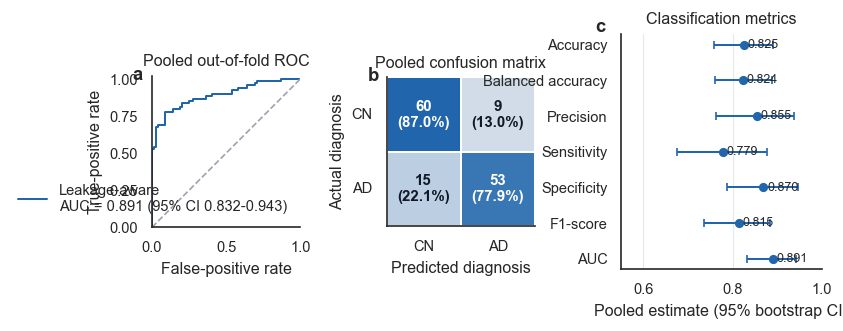

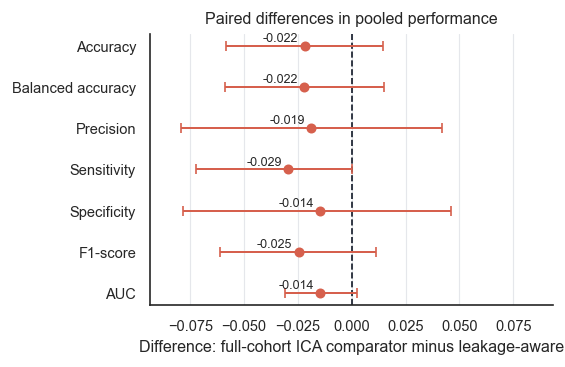

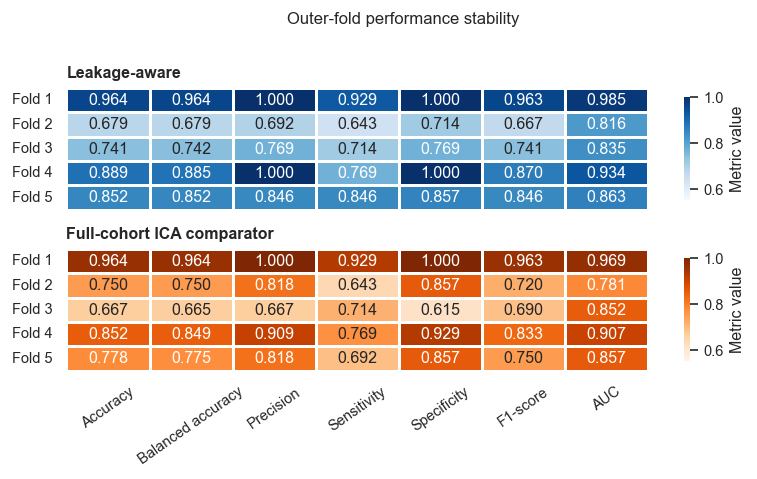

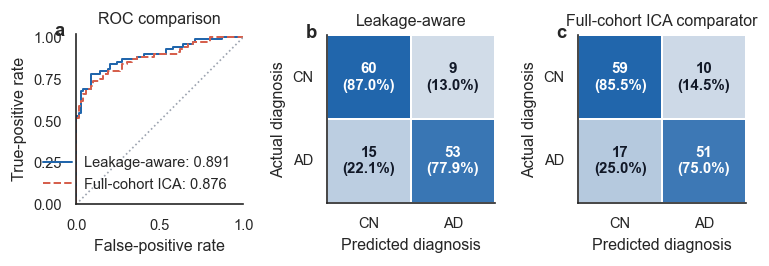

Figures saved to: H:\Master's Thesis\pipeline\analysis_outputs_checkpointed_relaxed\results\manuscript_figures
Primary ROC calculated from pooled out-of-fold decision scores.
Do not describe the full-cohort ICA comparator as a valid generalization model.


In [15]:
"""
Publication figures for the leakage-aware vs full-cohort ICA experiment.

Run in Jupyter with:
    %run visualize_fmri_results.py

Before running, set RESULTS_DIR to the folder containing:
    summary_metrics.csv
    paired_differences.csv
    fold_metrics.csv
    out_of_fold_predictions.csv

The script exports PDF (vector), TIFF (600 dpi), and PNG (300 dpi).
"""

import os
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

RESULTS_DIR = Path(
    os.environ.get(
        "FMRI_RESULTS_DIR",
        r"H:\Master's Thesis\pipeline\analysis_outputs_checkpointed_relaxed\results",
    )
)
OUTPUT_DIR = RESULTS_DIR / "manuscript_figures"

SUMMARY_FILE = RESULTS_DIR / "summary_metrics.csv"
DIFFERENCE_FILE = RESULTS_DIR / "paired_differences.csv"
FOLD_FILE = RESULTS_DIR / "fold_metrics.csv"
OOF_FILE = RESULTS_DIR / "out_of_fold_predictions.csv"

MODEL_LABELS = {
    "leakage_aware": "Leakage-aware",
    "leaky_ica": "Full-cohort ICA comparator",
}

METRIC_LABELS = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "precision": "Precision",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "f1": "F1-score",
    "auc": "AUC",
}

METRIC_ORDER = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1",
    "auc",
]

BLUE = "#2166AC"
ORANGE = "#D6604D"
GRAY = "#6B7280"


# ---------------------------------------------------------------------------
# Style and utility functions
# ---------------------------------------------------------------------------

mpl.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.6,
        "figure.dpi": 120,
        "savefig.bbox": "tight",
    }
)
sns.set_theme(style="white", context="paper")


def save_figure(fig, stem):
    """Save a figure in editable/vector and publication raster formats."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(
        OUTPUT_DIR / f"{stem}.tiff",
        dpi=600,
        bbox_inches="tight",
        pil_kwargs={"compression": "tiff_lzw"},
    )


def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")


def find_column(df, candidates, required=True):
    """Find a column using normalized aliases."""
    normalized = {normalize_name(col): col for col in df.columns}
    for candidate in candidates:
        key = normalize_name(candidate)
        if key in normalized:
            return normalized[key]
    if required:
        raise KeyError(
            f"Could not find any of {candidates}. Available columns: {list(df.columns)}"
        )
    return None


def model_mask(series, model):
    normalized = series.astype(str).map(normalize_name)
    aliases = {
        "leakage_aware": {
            "leakage_aware",
            "aware",
            "leakage_free",
            "valid",
        },
        "leaky_ica": {
            "leaky_ica",
            "leaky",
            "full_cohort_ica",
            "full_cohort",
        },
    }
    return normalized.isin(aliases[model])


def panel_label(ax, label):
    ax.text(
        -0.13,
        1.07,
        label,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
    )


def annotate_confusion_matrix(ax, cm, labels=("CN", "AD")):
    """Draw counts and row percentages without relying on a colorbar."""
    row_denominator = cm.sum(axis=1, keepdims=True)
    row_pct = np.divide(
        cm,
        row_denominator,
        out=np.zeros_like(cm, dtype=float),
        where=row_denominator != 0,
    )

    sns.heatmap(
        cm,
        cmap=sns.light_palette(BLUE, as_cmap=True),
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        annot=False,
        ax=ax,
        vmin=0,
        vmax=max(1, cm.max()),
    )

    threshold = cm.max() * 0.55
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            color = "white" if cm[row, col] > threshold else "#111827"
            ax.text(
                col + 0.5,
                row + 0.5,
                f"{cm[row, col]}\n({row_pct[row, col] * 100:.1f}%)",
                ha="center",
                va="center",
                color=color,
                fontsize=9,
                fontweight="bold",
            )

    ax.set_xticklabels(labels, rotation=0)
    ax.set_yticklabels(labels, rotation=0)
    ax.set_xlabel("Predicted diagnosis")
    ax.set_ylabel("Actual diagnosis")


# ---------------------------------------------------------------------------
# Data loading and normalization
# ---------------------------------------------------------------------------

summary = pd.read_csv(SUMMARY_FILE)
differences = pd.read_csv(DIFFERENCE_FILE)
fold_raw = pd.read_csv(FOLD_FILE)
oof = pd.read_csv(OOF_FILE)

summary.columns = [normalize_name(col) for col in summary.columns]
differences.columns = [normalize_name(col) for col in differences.columns]
fold_raw.columns = [normalize_name(col) for col in fold_raw.columns]
oof.columns = [normalize_name(col) for col in oof.columns]


def normalize_fold_metrics(df):
    """
    Accept either:
      1. wide data: model, fold, accuracy, ..., auc
      2. long data: model, fold, metric, value
    """
    model_col = find_column(df, ["model", "pipeline"])
    fold_col = find_column(df, ["fold", "outer_fold", "fold_id"])
    metric_col = find_column(df, ["metric"], required=False)
    value_col = find_column(
        df, ["value", "metric_value", "score"], required=False
    )

    if metric_col and value_col:
        long_df = df[[model_col, fold_col, metric_col, value_col]].copy()
        long_df.columns = ["model", "fold", "metric", "value"]
    else:
        present_metrics = [metric for metric in METRIC_ORDER if metric in df.columns]
        if not present_metrics:
            raise KeyError(
                "No recognized metric columns were found in fold_metrics.csv. "
                f"Available columns: {list(df.columns)}"
            )
        long_df = df.melt(
            id_vars=[model_col, fold_col],
            value_vars=present_metrics,
            var_name="metric",
            value_name="value",
        )
        long_df = long_df.rename(
            columns={model_col: "model", fold_col: "fold"}
        )

    long_df["model"] = long_df["model"].map(normalize_name)
    long_df["metric"] = long_df["metric"].map(normalize_name)
    long_df["fold"] = pd.to_numeric(long_df["fold"], errors="coerce")
    long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")
    return long_df.dropna(subset=["fold", "value"])


fold_long = normalize_fold_metrics(fold_raw)


def extract_oof_arrays(df):
    """
    Locate true labels, scores, and predictions from common column names.
    Edit the alias lists here only if your CSV uses different names.
    """
    true_col = find_column(
        df,
        ["y_true", "true_label", "label", "diagnosis_code", "target"],
    )

    aware_score_col = find_column(
        df,
        [
            "aware_score",
            "leakage_aware_score",
            "aware_decision_score",
            "leakage_aware_decision_score",
            "y_score_aware",
            "aware_probability",
        ],
    )
    leaky_score_col = find_column(
        df,
        [
            "leaky_score",
            "leaky_ica_score",
            "leaky_decision_score",
            "full_cohort_ica_score",
            "y_score_leaky",
            "leaky_probability",
        ],
    )

    aware_pred_col = find_column(
        df,
        [
            "aware_pred",
            "leakage_aware_pred",
            "aware_prediction",
            "leakage_aware_prediction",
            "y_pred_aware",
        ],
        required=False,
    )
    leaky_pred_col = find_column(
        df,
        [
            "leaky_pred",
            "leaky_ica_pred",
            "leaky_prediction",
            "full_cohort_ica_prediction",
            "y_pred_leaky",
        ],
        required=False,
    )

    y_true = df[true_col].copy()
    if y_true.dtype == object:
        y_true = (
            y_true.astype(str)
            .str.strip()
            .str.upper()
            .map({"CN": 0, "AD": 1, "0": 0, "1": 1})
        )
    y_true = pd.to_numeric(y_true, errors="coerce")

    aware_score = pd.to_numeric(df[aware_score_col], errors="coerce")
    leaky_score = pd.to_numeric(df[leaky_score_col], errors="coerce")

    aware_pred = (
        pd.to_numeric(df[aware_pred_col], errors="coerce")
        if aware_pred_col
        else (aware_score >= 0).astype(int)
    )
    leaky_pred = (
        pd.to_numeric(df[leaky_pred_col], errors="coerce")
        if leaky_pred_col
        else (leaky_score >= 0).astype(int)
    )

    valid = (
        y_true.notna()
        & aware_score.notna()
        & leaky_score.notna()
        & aware_pred.notna()
        & leaky_pred.notna()
    )
    return (
        y_true[valid].astype(int).to_numpy(),
        aware_score[valid].to_numpy(),
        leaky_score[valid].to_numpy(),
        aware_pred[valid].astype(int).to_numpy(),
        leaky_pred[valid].astype(int).to_numpy(),
    )


y_true, aware_score, leaky_score, aware_pred, leaky_pred = extract_oof_arrays(oof)


# ---------------------------------------------------------------------------
# Figure 2: Primary leakage-aware performance
# ---------------------------------------------------------------------------

aware_summary = summary[model_mask(summary["model"], "leakage_aware")].copy()
aware_summary["metric"] = aware_summary["metric"].map(normalize_name)
aware_summary = aware_summary.set_index("metric").reindex(METRIC_ORDER).dropna()

aware_auc = float(aware_summary.loc["auc", "pooled_value"])
aware_auc_low = float(aware_summary.loc["auc", "bootstrap_ci_low"])
aware_auc_high = float(aware_summary.loc["auc", "bootstrap_ci_high"])

fpr_aware, tpr_aware, _ = roc_curve(y_true, aware_score)
cm_aware = confusion_matrix(y_true, aware_pred, labels=[0, 1])

fig, axes = plt.subplots(
    1,
    3,
    figsize=(7.2, 2.55),
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.35]},
)

# A: pooled out-of-fold ROC
ax = axes[0]
ax.plot(
    fpr_aware,
    tpr_aware,
    color=BLUE,
    label=(
        f"Leakage-aware\nAUC = {aware_auc:.3f} "
        f"(95% CI {aware_auc_low:.3f}-{aware_auc_high:.3f})"
    ),
)
ax.plot([0, 1], [0, 1], linestyle="--", color="#9CA3AF", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.legend(loc="lower right", frameon=False)
ax.set_title("Pooled out-of-fold ROC")
panel_label(ax, "a")

# B: pooled confusion matrix
ax = axes[1]
annotate_confusion_matrix(ax, cm_aware)
ax.set_title("Pooled confusion matrix")
panel_label(ax, "b")

# C: pooled metrics with bootstrap confidence intervals
ax = axes[2]
plot_df = aware_summary.reset_index().iloc[::-1]
y_pos = np.arange(len(plot_df))
x = plot_df["pooled_value"].to_numpy()
x_low = plot_df["bootstrap_ci_low"].to_numpy()
x_high = plot_df["bootstrap_ci_high"].to_numpy()
ax.errorbar(
    x,
    y_pos,
    xerr=np.vstack([x - x_low, x_high - x]),
    fmt="o",
    color=BLUE,
    ecolor=BLUE,
    capsize=2.5,
    markersize=4.5,
)
ax.set_yticks(y_pos)
ax.set_yticklabels([METRIC_LABELS[m] for m in plot_df["metric"]])
ax.set_xlim(0.55, 1.0)
ax.set_xlabel("Pooled estimate (95% bootstrap CI)")
ax.set_title("Classification metrics")
ax.grid(axis="x", color="#E5E7EB", linewidth=0.7)
for y, value in zip(y_pos, x):
    ax.text(value + 0.008, y, f"{value:.3f}", va="center", fontsize=7.5)
panel_label(ax, "c")

sns.despine(fig=fig)
fig.subplots_adjust(wspace=0.52)
save_figure(fig, "Figure_2_primary_leakage_aware_performance")
plt.show()


# ---------------------------------------------------------------------------
# Figure 3: Paired comparison with intentionally contaminated comparator
# ---------------------------------------------------------------------------

differences["metric"] = differences["metric"].map(normalize_name)
diff_plot = differences.set_index("metric").reindex(METRIC_ORDER).dropna()
diff_plot = diff_plot.reset_index().iloc[::-1]

fig, ax = plt.subplots(figsize=(4.8, 3.15))
y_pos = np.arange(len(diff_plot))
x = diff_plot["difference_leaky_minus_aware"].to_numpy()
x_low = diff_plot["paired_bootstrap_ci_low"].to_numpy()
x_high = diff_plot["paired_bootstrap_ci_high"].to_numpy()

ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
ax.errorbar(
    x,
    y_pos,
    xerr=np.vstack([x - x_low, x_high - x]),
    fmt="o",
    color=ORANGE,
    ecolor=ORANGE,
    capsize=3,
    markersize=5,
)
ax.set_yticks(y_pos)
ax.set_yticklabels([METRIC_LABELS[m] for m in diff_plot["metric"]])
ax.set_xlabel("Difference: full-cohort ICA comparator minus leakage-aware")
ax.set_title("Paired differences in pooled performance")
ax.grid(axis="x", color="#E5E7EB", linewidth=0.7)

limit = max(abs(x_low.min()), abs(x_high.max())) * 1.18
ax.set_xlim(-limit, limit)
for y, value in zip(y_pos, x):
    horizontal_alignment = "right" if value < 0 else "left"
    offset = -0.003 if value < 0 else 0.003
    ax.text(
        value + offset,
        y + 0.18,
        f"{value:+.3f}",
        ha=horizontal_alignment,
        va="center",
        fontsize=7.5,
    )

sns.despine(fig=fig)
fig.tight_layout()
save_figure(fig, "Figure_3_paired_comparator_differences")
plt.show()


# ---------------------------------------------------------------------------
# Supplementary Figure S1: all outer-fold metrics
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(6.8, 3.9), sharex=True)

for ax, model, color_map in [
    (axes[0], "leakage_aware", "Blues"),
    (axes[1], "leaky_ica", "Oranges"),
]:
    model_data = fold_long[model_mask(fold_long["model"], model)].copy()
    pivot = model_data.pivot(index="fold", columns="metric", values="value")
    available_order = [metric for metric in METRIC_ORDER if metric in pivot.columns]
    pivot = pivot.reindex(columns=available_order).sort_index()
    pivot.columns = [METRIC_LABELS[metric] for metric in available_order]
    pivot.index = [f"Fold {int(fold)}" for fold in pivot.index]

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap=color_map,
        vmin=0.55,
        vmax=1.0,
        cbar_kws={"label": "Metric value", "shrink": 0.85},
        linewidths=0.7,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(MODEL_LABELS[model], loc="left", fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("")

axes[-1].tick_params(axis="x", rotation=35)
fig.suptitle("Outer-fold performance stability", y=1.01, fontsize=10)
fig.tight_layout()
save_figure(fig, "Supplementary_Figure_S1_outer_fold_metrics")
plt.show()


# ---------------------------------------------------------------------------
# Optional Supplementary Figure S2: direct ROC and confusion comparison
# ---------------------------------------------------------------------------

leaky_summary = summary[model_mask(summary["model"], "leaky_ica")].copy()
leaky_summary["metric"] = leaky_summary["metric"].map(normalize_name)
leaky_summary = leaky_summary.set_index("metric")
leaky_auc = float(leaky_summary.loc["auc", "pooled_value"])
leaky_auc_low = float(leaky_summary.loc["auc", "bootstrap_ci_low"])
leaky_auc_high = float(leaky_summary.loc["auc", "bootstrap_ci_high"])

fpr_leaky, tpr_leaky, _ = roc_curve(y_true, leaky_score)
cm_leaky = confusion_matrix(y_true, leaky_pred, labels=[0, 1])

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.45))

ax = axes[0]
ax.plot(
    fpr_aware,
    tpr_aware,
    color=BLUE,
    label=f"Leakage-aware: {aware_auc:.3f}",
)
ax.plot(
    fpr_leaky,
    tpr_leaky,
    color=ORANGE,
    linestyle="--",
    label=f"Full-cohort ICA: {leaky_auc:.3f}",
)
ax.plot([0, 1], [0, 1], linestyle=":", color="#9CA3AF", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_title("ROC comparison")
ax.legend(loc="lower right", frameon=False)
panel_label(ax, "a")

annotate_confusion_matrix(axes[1], cm_aware)
axes[1].set_title("Leakage-aware")
panel_label(axes[1], "b")

annotate_confusion_matrix(axes[2], cm_leaky)
axes[2].set_title("Full-cohort ICA comparator")
panel_label(axes[2], "c")

sns.despine(fig=fig)
fig.subplots_adjust(wspace=0.5)
save_figure(fig, "Supplementary_Figure_S2_model_comparison")
plt.show()


print(f"Figures saved to: {OUTPUT_DIR}")
print("Primary ROC calculated from pooled out-of-fold decision scores.")
print("Do not describe the full-cohort ICA comparator as a valid generalization model.")
